In [1]:
! pip install torch_geometric

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import requests
import os
import json
import pandas as pd
import gzip, json
from collections import defaultdict, Counter
from torch_geometric.data import Data

/home/infres/aellefi-25/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
urls = {"meta":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Toys_and_Games.json.gz","reviews":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Toys_and_Games.json.gz"}
for name, url in urls.items():
  file_name = f"{name}_Toys_and_Games.json.gz"
  if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    response = requests.get(url)
    with open(file_name, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Done!")
  else:
    print(f"Already exists: {file_name}")


Already exists: meta_Toys_and_Games.json.gz
Already exists: reviews_Toys_and_Games.json.gz


In [4]:
def parse_gz(path):
    with gzip.open(path, "rb") as f:
        for line in f:
            try:
                yield json.loads(line)
            except:
                try:
                    yield eval(line)
                except:
                    pass

# Count labels at each depth level
by_depth = defaultdict(Counter)

for item in parse_gz("meta_Toys_and_Games.json.gz"):
    for path in item.get("categories", []):
        for depth, label in enumerate(path):
            by_depth[depth][label] += 1

for depth in sorted(by_depth.keys()):
    print(f"\n Level {depth} ({len(by_depth[depth])} unique labels) ")
    for label, count in by_depth[depth].most_common(20):
        print(f"  {count:>6}  {label}")


 Level 0 (22 unique labels) 
  336460  Toys & Games
     753  Clothing, Shoes & Jewelry
     491  Sports & Outdoors
     248  Video Games
     119  Health & Personal Care
      69  Cell Phones & Accessories
      55  Software
      23  Baby Products
      22  Electronics
      14  Home & Kitchen
      12  Books
      12  Kindle Store
       9  Tools & Home Improvement
       7  Musical Instruments
       7  Beauty
       5  Arts, Crafts & Sewing
       3  Automotive
       2  Movies & TV
       2  Industrial & Scientific
       1  Patio, Lawn & Garden

 Level 1 (118 unique labels) 
   48885  Action Figures & Statues
   38838  Games
   34812  Stuffed Animals & Plush
   26325  Hobbies
   22167  Dolls & Accessories
   19680  Toy Remote Control & Play Vehicles
   17649  Party Supplies
   14666  Arts & Crafts
   14545  Sports & Outdoor Play
   13659  Puzzles
   12569  Learning & Education
   11725  Novelty & Gag Toys
   10116  Building Toys
    9317  Grown-Up Toys
    9105  Dress Up & Pret

In [5]:
records = []

for item in parse_gz("meta_Toys_and_Games.json.gz"):
    records.append(item)

df = pd.DataFrame(records)
print(df.shape)
print(df.columns.tolist())

(336072, 9)
['asin', 'description', 'title', 'price', 'salesRank', 'imUrl', 'brand', 'categories', 'related']


In [6]:
df.head()

,asin,description,title,price,salesRank,imUrl,brand,categories,related
0,0000191639,"Three Dr. Suess' Puzzles: Green Eggs and Ham, ...",Dr. Suess 19163 Dr. Seuss Puzzle 3 Pack Bundle,37.12,{'Toys & Games': 612379},http://ecx.images-amazon.com/images/I/414PLROX...,Dr. Seuss,"[[Toys & Games, Puzzles, Jigsaw Puzzles]]",NaN
1,0005069491,NaN,Nursery Rhymes Felt Book,NaN,{'Toys & Games': 576683},http://ecx.images-amazon.com/images/I/51z4JDBC...,NaN,[[Toys & Games]],NaN
2,0076561046,Learn Fractions Decimals Percents using flash ...,Fraction Decimal Percent Card Deck,NaN,{'Toys & Games': 564211},http://ecx.images-amazon.com/images/I/51ObabPu...,NaN,"[[Toys & Games, Learning & Education, Flash Ca...",{'also_viewed': ['0075728680']}
3,0131358936,"New, Sealed. Fast Shipping with tracking, buy ...",NaN,36.22,{'Software': 8080},http://ecx.images-amazon.com/images/I/51%2B7Ej...,NaN,"[[Toys & Games, Learning & Education, Mathemat...","{'also_bought': ['0321845536', '0078787572'], ..."
4,0133642984,NaN,Algebra 2 California Teacher Center,731.93,{'Toys & Games': 1150291},http://ecx.images-amazon.com/images/I/51VK%2BL...,Prentice Hall,"[[Toys & Games, Learning & Education, Mathemat...",NaN


In [7]:
df.dtypes

asin               str
description        str
title              str
price          float64
salesRank       object
imUrl              str
brand              str
categories      object
related         object
dtype: object

In [8]:
df.isnull().sum()

asin                0
description     33285
title             898
price           93381
salesRank        8849
imUrl             350
brand          150706
categories          0
related         71687
dtype: int64

In [9]:
df['description'].notna().sum()

302787

In [11]:
both_missing = df['title'].isna() & df['description'].isna()
print(both_missing.sum())

406


In [12]:
import torch
from torch_geometric.data import Data

# map every asin to an integer index
asin2idx = {asin: i for i, asin in enumerate(df['asin'])}

# build edge list
src_list = []
dst_list = []

edge_types = ['also_bought']

for _, row in df.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

# add both directions
src_all = src_list + dst_list
dst_all = dst_list + src_list

#  remove duplicates
edges = set()
src_clean = []
dst_clean = []

for s, d in zip(src_all, dst_all):
    if s == d:
        continue
    if (s, d) in edges:
        continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)


edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)

print(f"Nodes:          {len(asin2idx)}")
print(f"Edges:          {edge_index.shape[1]}")

degree = Counter()
for src in edge_index[0].tolist():
    degree[src] += 1
print(f"Isolated nodes: {len(asin2idx) - len(degree)}")
print(f"Connected nodes: {len(degree)}")

Nodes:          336072
Edges:          7791014
Isolated nodes: 155213
Connected nodes: 180859


In [ ]:
def get_label(categories):
    if not categories:
        return None
    for path in categories:
        if path and path[0] == 'Toys & Games' and len(path) >= 2:
            return path[1]
    return None  

df['label'] = df['categories'].apply(get_label)

df = df[df['label'].notna()].reset_index(drop=True)

print(f"Products after dropping level-0 only: {len(df)}")
print(f"Unique labels: {df['label'].nunique()}")
print()
print(df['label'].value_counts())

Products after dropping level-0 only: 317329
Unique labels: 18

label
Action Figures & Statues              48875
Games                                 38817
Stuffed Animals & Plush               34805
Hobbies                               26322
Dolls & Accessories                   22150
Toy Remote Control & Play Vehicles    19678
Party Supplies                        17566
Arts & Crafts                         14666
Sports & Outdoor Play                 14542
Puzzles                               13655
Learning & Education                  12541
Novelty & Gag Toys                    11720
Building Toys                         10116
Grown-Up Toys                          9256
Dress Up & Pretend Play                9066
Electronics for Kids                   6277
Baby & Toddler Toys                    5145
Tricycles, Scooters & Wagons           2132
Name: count, dtype: int64


In [14]:
label_counts = df['label'].value_counts()

print(f"Classes with >= 100 products: {(label_counts >= 100).sum()}")
print(f"Classes with >= 50 products:  {(label_counts >= 50).sum()}")
print(f"Classes with >= 10 products:  {(label_counts >= 10).sum()}")
print(f"Classes with < 10 products:   {(label_counts < 10).sum()}")
print(f"Classes with 1 product:       {(label_counts == 1).sum()}")
print()
print(f"Products in classes >= 100:   {label_counts[label_counts >= 100].sum()}")
print(f"Products in classes < 10:     {label_counts[label_counts < 10].sum()}")

Classes with >= 100 products: 18
Classes with >= 50 products:  18
Classes with >= 10 products:  18
Classes with < 10 products:   0
Classes with 1 product:       0

Products in classes >= 100:   317329
Products in classes < 10:     0


In [15]:
# encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])

print(f"Classes: {df['label_idx'].nunique()}")
print(df[['label', 'label_idx']].drop_duplicates().sort_values('label_idx'))

Classes: 18
                                   label  label_idx
75              Action Figures & Statues          0
6                          Arts & Crafts          1
744                  Baby & Toddler Toys          2
95                         Building Toys          3
4                    Dolls & Accessories          4
18               Dress Up & Pretend Play          5
24                  Electronics for Kids          6
7                                  Games          7
310                        Grown-Up Toys          8
430                              Hobbies          9
1                   Learning & Education         10
17                    Novelty & Gag Toys         11
12                        Party Supplies         12
0                                Puzzles         13
315                Sports & Outdoor Play         14
10               Stuffed Animals & Plush         15
47    Toy Remote Control & Play Vehicles         16
2170        Tricycles, Scooters & Wagons         17


In [16]:
# rebuild asin2idx on df (no filtering needed, all 317k products kept)
asin2idx = {asin: i for i, asin in enumerate(df['asin'])}

src_list, dst_list = [], []
edge_types = ['also_bought']  

for _, row in df.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

src_all = src_list + dst_list
dst_all = dst_list + src_list

edges = set()
src_clean, dst_clean = [], []
for s, d in zip(src_all, dst_all):
    if s == d: continue
    if (s, d) in edges: continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)

edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)
print(f"Nodes: {len(asin2idx)}")
print(f"Edges: {edge_index.shape[1]}")

# check isolation
degree = Counter()
for src in edge_index[0].tolist():
    degree[src] += 1
print(f"Isolated nodes: {len(asin2idx) - len(degree)}")
print(f"Connected nodes: {len(degree)}")

Nodes: 317329
Edges: 7492956
Isolated nodes: 142207
Connected nodes: 175122


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

# combine title and description
df['text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')
df['text'] = df['text'].str.strip()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['text'])

# reduce to 128 dims with SVD (same as PCA but works on sparse matrices)
svd = TruncatedSVD(n_components=128, random_state=42)
X_bow = svd.fit_transform(X_tfidf)

print(f"Feature matrix shape: {X_bow.shape}")
print(f"Explained variance:   {svd.explained_variance_ratio_.sum():.2%}")

Feature matrix shape: (317329, 128)
Explained variance:   18.33%


In [18]:
x = torch.tensor(X_bow, dtype=torch.float)
y = torch.tensor(df['label_idx'].values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)
print(data)

Data(x=[317329, 128], edge_index=[2, 7492956], y=[317329])


In [19]:
from sklearn.model_selection import train_test_split

idx = torch.arange(len(df))

# first split off test set
idx_train_val, idx_test = train_test_split(
    idx, test_size=0.15, random_state=42,
    stratify=df['label_idx']
)

# then split train and val
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.15/0.85, random_state=42,
    stratify=df.loc[idx_train_val.numpy(), 'label_idx']
)

data.train_mask = torch.zeros(len(df), dtype=torch.bool)
data.val_mask   = torch.zeros(len(df), dtype=torch.bool)
data.test_mask  = torch.zeros(len(df), dtype=torch.bool)

data.train_mask[idx_train] = True
data.val_mask[idx_val]     = True
data.test_mask[idx_test]   = True

print(f"Train: {data.train_mask.sum()} ({data.train_mask.sum()/len(df):.0%})")
print(f"Val:   {data.val_mask.sum()} ({data.val_mask.sum()/len(df):.0%})")
print(f"Test:  {data.test_mask.sum()} ({data.test_mask.sum()/len(df):.0%})")

Train: 222129 (70%)
Val:   47600 (15%)
Test:  47600 (15%)


In [20]:
print(data)

Data(x=[317329, 128], edge_index=[2, 7492956], y=[317329], train_mask=[317329], val_mask=[317329], test_mask=[317329])


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

model = MLP(
    in_channels=128,      # BoW feature size
    hidden_channels=256,  # hidden layer size
    out_channels=142      # number of classes
)
print(model)

MLP(
  (lin1): Linear(in_features=128, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=142, bias=True)
)


In [22]:
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

data = data.to(device)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x)
    pred = out.argmax(dim=1)

    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()

    return train_acc.item(), val_acc.item(), test_acc.item()

# training loop
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = evaluate()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Using device: cuda
Epoch  20 | Loss: 2.2517 | Train: 0.4339 | Val: 0.4310 | Test: 0.4314
Epoch  40 | Loss: 1.3471 | Train: 0.6646 | Val: 0.6648 | Test: 0.6648
Epoch  60 | Loss: 1.2171 | Train: 0.6871 | Val: 0.6862 | Test: 0.6853
Epoch  80 | Loss: 1.1874 | Train: 0.6924 | Val: 0.6920 | Test: 0.6916
Epoch 100 | Loss: 1.1719 | Train: 0.6958 | Val: 0.6954 | Test: 0.6950
Epoch 120 | Loss: 1.1602 | Train: 0.6970 | Val: 0.6967 | Test: 0.6963
Epoch 140 | Loss: 1.1516 | Train: 0.6986 | Val: 0.6985 | Test: 0.6979
Epoch 160 | Loss: 1.1448 | Train: 0.6994 | Val: 0.6990 | Test: 0.6986
Epoch 180 | Loss: 1.1395 | Train: 0.6996 | Val: 0.6987 | Test: 0.6990
Epoch 200 | Loss: 1.1359 | Train: 0.7003 | Val: 0.6995 | Test: 0.6997

Best Val Acc:  0.7002
Best Test Acc: 0.7001


In [23]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_sage = GraphSAGE(128, 256, 142).to(device)
optimizer_sage = Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)

def train_sage():
    model_sage.train()
    optimizer_sage.zero_grad()
    out = model_sage(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_sage.step()
    return loss.item()

@torch.no_grad()
def evaluate_sage():
    model_sage.eval()
    out = model_sage(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()
    return train_acc.item(), val_acc.item(), test_acc.item()

best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train_sage()
    train_acc, val_acc, test_acc = evaluate_sage()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch  20 | Loss: 1.6548 | Train: 0.6308 | Val: 0.6278 | Test: 0.6292
Epoch  40 | Loss: 1.1483 | Train: 0.7142 | Val: 0.7116 | Test: 0.7131
Epoch  60 | Loss: 1.0807 | Train: 0.7229 | Val: 0.7206 | Test: 0.7222
Epoch  80 | Loss: 1.0616 | Train: 0.7266 | Val: 0.7246 | Test: 0.7268
Epoch 100 | Loss: 1.0483 | Train: 0.7281 | Val: 0.7261 | Test: 0.7284
Epoch 120 | Loss: 1.0377 | Train: 0.7290 | Val: 0.7271 | Test: 0.7291
Epoch 140 | Loss: 1.0316 | Train: 0.7295 | Val: 0.7279 | Test: 0.7299
Epoch 160 | Loss: 1.0262 | Train: 0.7303 | Val: 0.7283 | Test: 0.7305
Epoch 180 | Loss: 1.0232 | Train: 0.7308 | Val: 0.7291 | Test: 0.7309
Epoch 200 | Loss: 1.0176 | Train: 0.7308 | Val: 0.7292 | Test: 0.7309

Best Val Acc:  0.7296
Best Test Acc: 0.7309


In [24]:
!pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable


### BERT

In [ ]:
from sentence_transformers import SentenceTransformer

model_bert = SentenceTransformer('all-MiniLM-L6-v2')  

texts = df['text'].tolist()
X_bert = model_bert.encode(texts, batch_size=256, show_progress_bar=True)

print(f"BERT embeddings shape: {X_bert.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1240 [00:00<?, ?it/s]

BERT embeddings shape: (317329, 384)


In [26]:
from sentence_transformers import SentenceTransformer

model_bert_large = SentenceTransformer('all-mpnet-base-v2')
texts = df['text'].tolist()
X_bert_large = model_bert_large.encode(texts, batch_size=128, show_progress_bar=True)

print(f"Shape: {X_bert_large.shape}")  

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2480 [00:00<?, ?it/s]

Shape: (317329, 768)


In [27]:
import matplotlib.pyplot as plt

def train_sage_full(x_features, in_channels, model_name="GraphSAGE",
                    epochs=300, patience=20, lr=0.01):


    data.x = torch.tensor(x_features, dtype=torch.float).to(device)

    # model
    model = GraphSAGE(in_channels, 256, 142).to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    history = {'train': [], 'val': [], 'test': [], 'loss': []}
    best_val_acc = 0
    best_test_acc = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # evaluate
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
            test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

        history['train'].append(train_acc)
        history['val'].append(val_acc)
        history['test'].append(test_acc)
        history['loss'].append(loss.item())

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    print(f"\nBest Val Acc:  {best_val_acc:.4f}")
    print(f"Best Test Acc: {best_test_acc:.4f}")

    # plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train'], label='Train')
    plt.plot(history['val'], label='Val')
    plt.plot(history['test'], label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return best_val_acc, best_test_acc

 GraphSAGE + BoW 
Epoch  20 | Loss: 1.6743 | Train: 0.6270 | Val: 0.6239 | Test: 0.6251
Epoch  40 | Loss: 1.1510 | Train: 0.7147 | Val: 0.7123 | Test: 0.7138
Epoch  60 | Loss: 1.0834 | Train: 0.7226 | Val: 0.7203 | Test: 0.7226
Epoch  80 | Loss: 1.0566 | Train: 0.7269 | Val: 0.7248 | Test: 0.7274
Epoch 100 | Loss: 1.0448 | Train: 0.7284 | Val: 0.7263 | Test: 0.7290
Epoch 120 | Loss: 1.0357 | Train: 0.7288 | Val: 0.7264 | Test: 0.7289
Epoch 140 | Loss: 1.0297 | Train: 0.7297 | Val: 0.7278 | Test: 0.7296
Epoch 160 | Loss: 1.0252 | Train: 0.7300 | Val: 0.7285 | Test: 0.7304
Epoch 180 | Loss: 1.0220 | Train: 0.7304 | Val: 0.7289 | Test: 0.7302
Epoch 200 | Loss: 1.0186 | Train: 0.7306 | Val: 0.7288 | Test: 0.7305
Early stopping at epoch 201

Best Val Acc:  0.7292
Best Test Acc: 0.7307


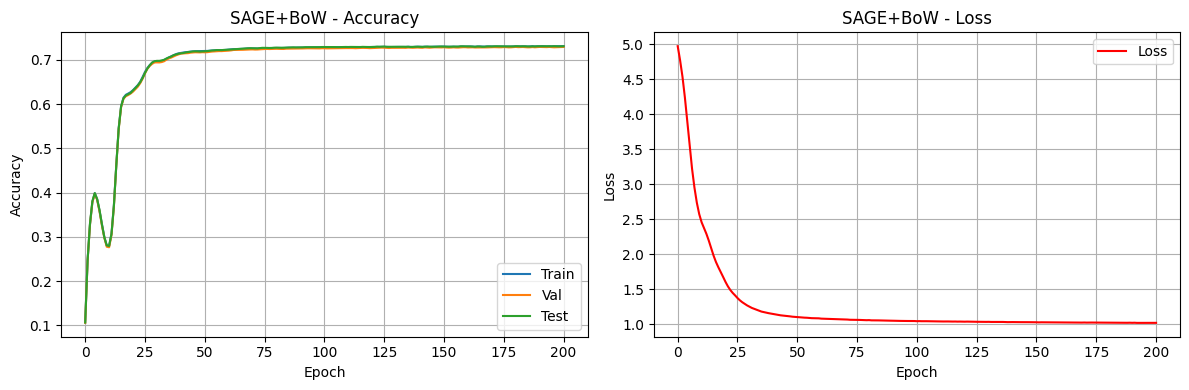

 GraphSAGE + BERT MiniLM 
Epoch  20 | Loss: 1.3479 | Train: 0.6624 | Val: 0.6615 | Test: 0.6605
Epoch  40 | Loss: 1.0631 | Train: 0.7238 | Val: 0.7202 | Test: 0.7218
Epoch  60 | Loss: 0.9853 | Train: 0.7446 | Val: 0.7403 | Test: 0.7418
Epoch  80 | Loss: 0.9434 | Train: 0.7535 | Val: 0.7503 | Test: 0.7504
Epoch 100 | Loss: 0.9231 | Train: 0.7576 | Val: 0.7537 | Test: 0.7546
Epoch 120 | Loss: 0.9107 | Train: 0.7595 | Val: 0.7553 | Test: 0.7559
Epoch 140 | Loss: 0.9039 | Train: 0.7610 | Val: 0.7568 | Test: 0.7569
Epoch 160 | Loss: 0.8973 | Train: 0.7616 | Val: 0.7570 | Test: 0.7573
Epoch 180 | Loss: 0.8935 | Train: 0.7629 | Val: 0.7581 | Test: 0.7582
Early stopping at epoch 195

Best Val Acc:  0.7584
Best Test Acc: 0.7579


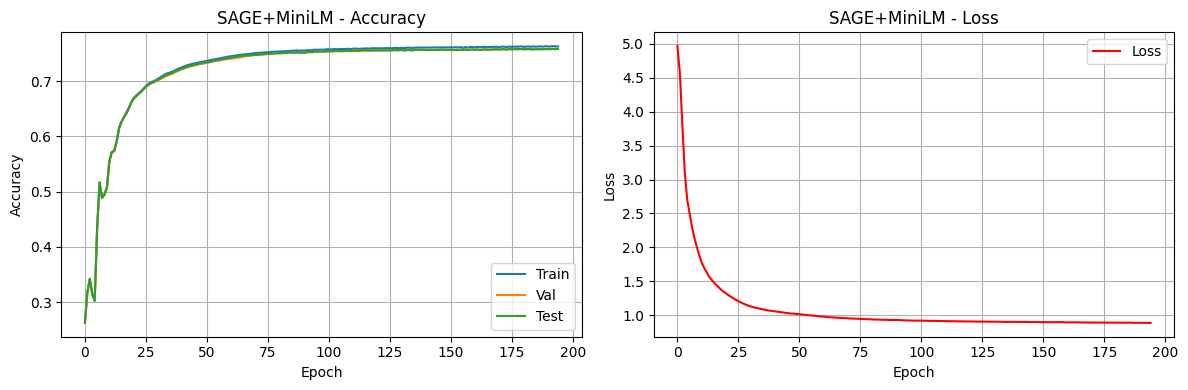

GraphSAGE + BERT large


OutOfMemoryError: CUDA out of memory. Tried to allocate 21.44 GiB. GPU 0 has a total capacity of 15.89 GiB of which 11.33 GiB is free. Including non-PyTorch memory, this process has 4.55 GiB memory in use. Of the allocated memory 1.54 GiB is allocated by PyTorch, and 2.72 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# BoW baseline
print(" GraphSAGE + BoW ")
val_bow, test_bow = train_sage_full(X_bow, in_channels=128, model_name="SAGE+BoW")

# BERT small 
print(" GraphSAGE + BERT MiniLM ")
val_minilm, test_minilm = train_sage_full(X_bert, in_channels=384, model_name="SAGE+MiniLM")



### CLIP

In [ ]:
from transformers import CLIPTokenizer, CLIPTextModel
import torch
import numpy as np


clip_text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

texts = df['text'].tolist()
X_clip_text = []

clip_text_model.eval()
batch_size = 256

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = clip_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        ).to(device)
        outputs = clip_text_model(**inputs)
        # extract pooled output → the [CLS] token embedding
        embeddings = outputs.pooler_output  # ← this is the tensor
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
        X_clip_text.append(embeddings.cpu().numpy())
        if i % 10000 == 0:
            print(f"Processed {i}/{len(texts)}")

X_clip_text = np.vstack(X_clip_text)
print(f"CLIP text embeddings shape: {X_clip_text.shape}")

 GraphSAGE + CLIP text 
Epoch  20 | Loss: 1.6177 | Train: 0.6292 | Val: 0.6229 | Test: 0.6286
Epoch  40 | Loss: 1.2284 | Train: 0.7060 | Val: 0.6960 | Test: 0.7062
Epoch  60 | Loss: 1.1509 | Train: 0.7262 | Val: 0.7180 | Test: 0.7242
Epoch  80 | Loss: 1.1261 | Train: 0.7302 | Val: 0.7202 | Test: 0.7277
Epoch 100 | Loss: 1.1093 | Train: 0.7353 | Val: 0.7227 | Test: 0.7300
Epoch 120 | Loss: 1.1013 | Train: 0.7372 | Val: 0.7246 | Test: 0.7302
Epoch 140 | Loss: 1.1003 | Train: 0.7383 | Val: 0.7242 | Test: 0.7316
Epoch 160 | Loss: 1.0940 | Train: 0.7395 | Val: 0.7264 | Test: 0.7324
Early stopping at epoch 173

Best Val Acc:  0.7282
Best Test Acc: 0.7316


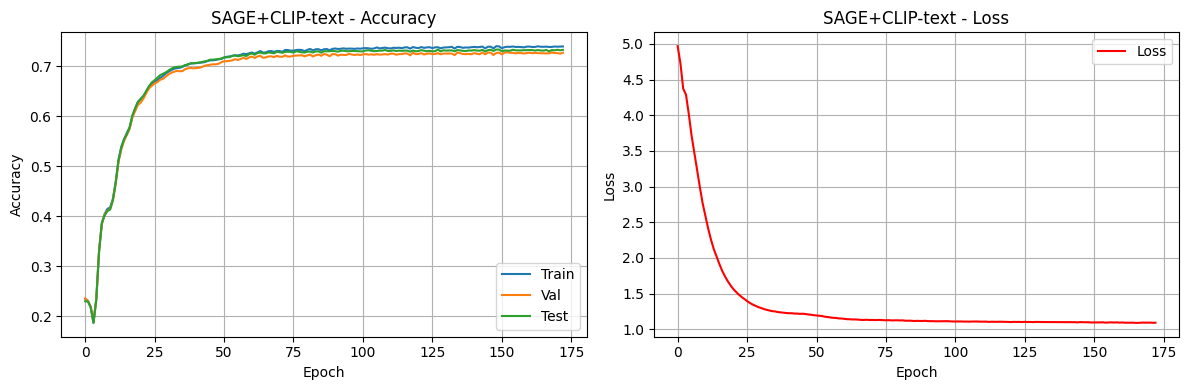

In [35]:
print(" GraphSAGE + CLIP text ")
val_clip, test_clip = train_sage_full(
    X_clip_text,
    in_channels=512,
    model_name="SAGE+CLIP-text"
)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

def get_qwen_embeddings(model_name, texts, batch_size=64):
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
    model.eval()

    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)
            outputs = model(**inputs)
            # mean pooling
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            emb = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            embeddings.append(emb.cpu().float().numpy())
            if i % 5000 == 0:
                print(f"  {i}/{len(texts)}")

    return np.vstack(embeddings)

texts = df['text'].tolist()
X_qwen_06b = get_qwen_embeddings("Qwen/Qwen3-Embedding-0.6B", texts)
print(f"Shape: {X_qwen_06b.shape}")

Loading Qwen/Qwen3-Embedding-0.6B...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  0/77808


KeyboardInterrupt: 